# 01 - Analise Exploratoria (EDA)

**O que este notebook faz:** carrega o dataset bruto, verifica a qualidade dos dados (nulos, duplicadas), explora a distribuicao do preco de venda e como ela varia por produto/regiao/estado/bandeira, e faz uma primeira olhada visual em possiveis outliers — tudo sem treinar nenhum modelo. E o passo 1 do fluxo EDA -> baseline -> modelos -> tuning -> avaliacao.

**Dataset:** Serie Historica de Precos de Combustiveis - ANP (Agencia Nacional do Petroleo, Gas Natural e Biocombustiveis)

Levantamento mensal de precos de venda de gasolina, gasolina aditivada e etanol por posto revendedor, coletado pela ANP em todo o Brasil. Fonte publica: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis (referencia: dezembro/2025).

**Por que este dataset serve para deteccao de anomalias?** Nao existe rotulo de fraude/erro, mas o problema e naturalmente desbalanceado no sentido que interessa: a grande maioria dos postos vende pelo preco de mercado da sua regiao/produto, e so uma pequena fracao tem precos muito fora do padrao (erro de digitacao no boletim, posto muito acima ou abaixo da concorrencia). E exatamente o cenario de IsolationForest, LocalOutlierFactor e OneClassSVM: aprender o que e 'normal' e apontar os poucos pontos que destoam.

**Este notebook e SOMENTE EDA.** Nao ha split treino/teste nem modelagem aqui — isso comeca no notebook `02_preprocessing_baseline`.

## 1. Imports

In [1]:
import sys
sys.path.append('..')  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import carregar_dados  # funcao reutilizavel de carga/limpeza

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = '../data/precos_combustiveis_anp_2025-12.csv'

df = carregar_dados(CAMINHO_DADOS)
print('Linhas x Colunas:', df.shape)
df.head()

Linhas x Colunas: (52336, 10)


,regiao,estado,municipio,revenda,cnpj_revenda,produto,data_coleta,valor_venda,unidade_medida,bandeira
0,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA,2025-12-01,6.14,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA ADITIVADA,2025-12-01,6.14,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,ETANOL,2025-12-01,4.79,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA,2025-12-01,6.19,R$ / litro,BRANCA
4,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA ADITIVADA,2025-12-01,6.19,R$ / litro,BRANCA


**Resultado:** 52.336 registros e 10 colunas. `carregar_dados` ja descarta as colunas de endereco (rua, numero, complemento, bairro, cep) e a coluna `Valor de Compra` (100% vazia no arquivo original), que nao ajudam a explicar preco anomalo.

## 3. Visao geral e qualidade dos dados

Cada linha e uma coleta de preco: um produto (gasolina, gasolina aditivada ou etanol) vendido por um posto, em uma data especifica.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52336 entries, 0 to 52335
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   regiao          52336 non-null  str           
 1   estado          52336 non-null  str           
 2   municipio       52336 non-null  str           
 3   revenda         52336 non-null  str           
 4   cnpj_revenda    52336 non-null  str           
 5   produto         52336 non-null  str           
 6   data_coleta     52336 non-null  datetime64[us]
 7   valor_venda     52336 non-null  float64       
 8   unidade_medida  52336 non-null  str           
 9   bandeira        52336 non-null  str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 4.0 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
regiao,52336,5,SE,25722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado,52336,27,SP,15534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,52336,397,SAO PAULO,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenda,52336,5103,SIM REDE DE POSTOS LTDA,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cnpj_revenda,52336,5737,08.505.094/0001-62,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto,52336,3,GASOLINA,19948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_coleta,52336,NaN,NaN,NaN,2025-12-15 14:40:57.597065,2025-12-01 00:00:00,2025-12-08 00:00:00,2025-12-16 00:00:00,2025-12-23 00:00:00,2025-12-31 00:00:00,NaN
valor_venda,52336.0,NaN,NaN,NaN,5.728101,3.49,4.79,5.99,6.39,9.59,0.908264
unidade_medida,52336,1,R$ / litro,52336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bandeira,52336,45,BRANCA,17003,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

Series([], dtype: int64)

In [6]:
# Linhas duplicadas (mesmo posto + produto + data + preco)
print('Duplicadas:', df.duplicated().sum())

Duplicadas: 0


**Resultado:** nenhuma coluna com valor nulo e nenhuma linha duplicada. Os dados ja chegam limpos o suficiente para seguir direto para a analise — nao ha necessidade de imputacao ou deduplicacao antes do split treino/teste.

## 4. Cobertura geografica e temporal

Quantos estados/regioes estao representados e qual o periodo coberto — importante para saber se faz sentido comparar precos entre estados.

In [7]:
print('Estados:', df['estado'].nunique())
print('Regioes:', sorted(df['regiao'].unique()))
print('Periodo:', df['data_coleta'].min().date(), 'a', df['data_coleta'].max().date())
print('Bandeiras (marcas):', df['bandeira'].nunique())

Estados: 27
Regioes: ['CO', 'N', 'NE', 'S', 'SE']
Periodo: 2025-12-01 a 2025-12-31
Bandeiras (marcas): 45


In [8]:
df['produto'].value_counts().to_frame('registros')

,registros
produto,
GASOLINA,19948
ETANOL,16747
GASOLINA ADITIVADA,15641


**Resultado:** cobertura nacional completa — os 27 estados e as 5 regioes aparecem na base, com coleta ao longo de todo dezembro/2025 e 45 bandeiras distintas. Os 3 produtos tambem estao bem distribuidos (38% gasolina, 32% etanol, 30% gasolina aditivada), o que da uma base solida para estratificar o split treino/teste por `produto` no notebook 02 e para calcular medianas de referencia confiaveis por estado/produto.

## 5. Distribuicao do preco de venda

Preco (`valor_venda`) e a unica variavel numerica de interesse direto — e a partir dela que as futuras features de anomalia serao construidas.

In [9]:
df['valor_venda'].describe()

count    52336.000000
mean         5.728101
std          0.908264
min          3.490000
25%          4.790000
50%          5.990000
75%          6.390000
max          9.590000
Name: valor_venda, dtype: float64

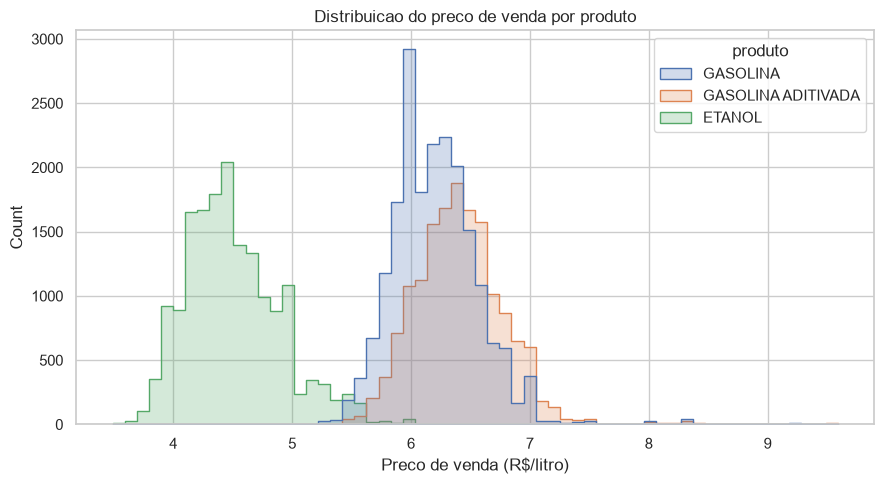

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='valor_venda', hue='produto', bins=60, element='step', ax=ax)
ax.set_title('Distribuicao do preco de venda por produto')
ax.set_xlabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_distribuicao_preco_por_produto.png', dpi=120)
plt.show()

**Resultado:** preco varia de R$ 3,49 a R$ 9,59 (media R$ 5,73). O histograma mostra tres distribuicoes bem separadas — etanol forma um agrupamento mais barato e a esquerda, gasolina e gasolina aditivada ficam mais caras e proximas entre si. Ou seja: o mesmo preco absoluto pode ser normal para um produto e anomalo para outro, entao qualquer analise de anomalia precisa comparar o preco dentro do proprio produto (e, como veremos a seguir, dentro da propria regiao).

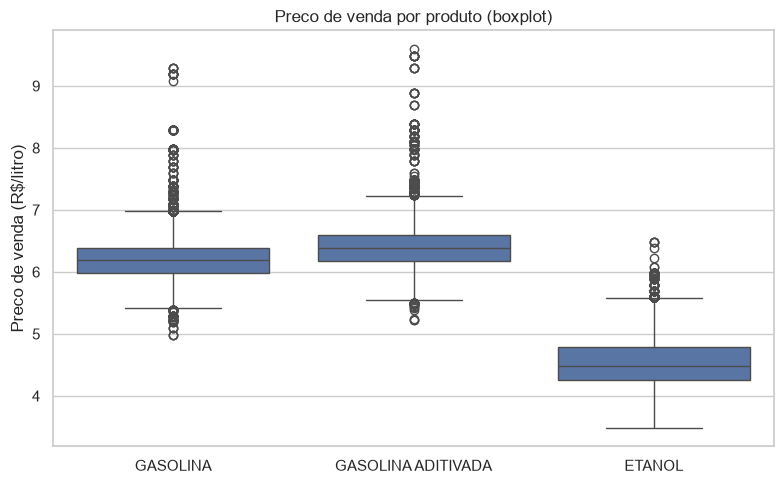

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='produto', y='valor_venda', ax=ax)
ax.set_title('Preco de venda por produto (boxplot)')
ax.set_xlabel('')
ax.set_ylabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.show()

**Resultado:** o boxplot confirma o etanol como o produto mais barato e com maior espalhamento relativo. Ja aparecem pontos fora dos bigodes (outliers univariados) nos tres produtos — candidatos naturais a anomalia, que os modelos dos proximos notebooks vao tentar capturar de forma sistematica.

## 6. Preco por regiao

Combustivel no Brasil varia bastante por regiao (frete, tributacao estadual). Ver essa variacao ajuda a decidir se a feature de anomalia deve comparar o preco contra a media nacional ou contra a media regional/estadual (decisao tomada no notebook 02).

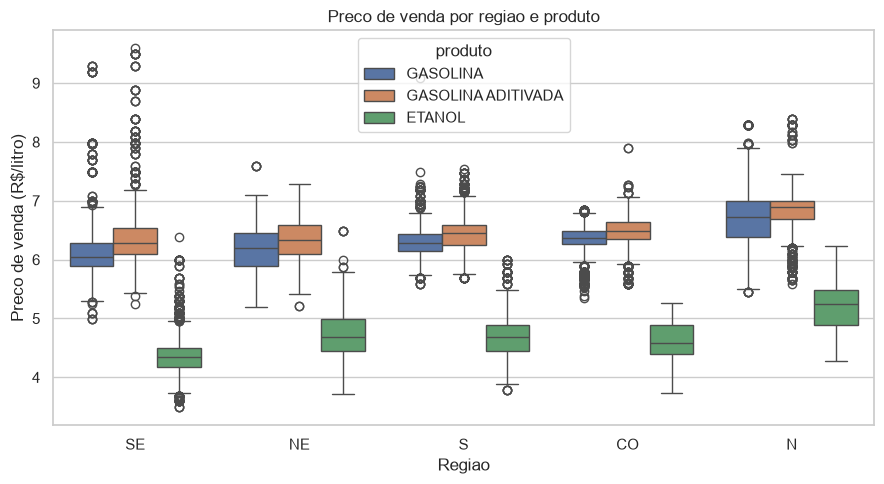

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem_regiao = df.groupby('regiao')['valor_venda'].median().sort_values().index
sns.boxplot(data=df, x='regiao', y='valor_venda', order=ordem_regiao, hue='produto', ax=ax)
ax.set_title('Preco de venda por regiao e produto')
ax.set_xlabel('Regiao')
ax.set_ylabel('Preco de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_boxplot_preco_por_regiao.png', dpi=120)
plt.show()

In [13]:
mediana_estado = (
    df.groupby(['estado', 'produto'])['valor_venda']
    .median()
    .unstack('produto')
    .sort_values('GASOLINA')
)
mediana_estado

produto,ETANOL,GASOLINA,GASOLINA ADITIVADA
estado,,,
PI,4.490,5.79,6.020
PB,4.190,5.89,6.070
RN,4.490,5.94,6.030
MA,5.090,5.99,6.090
SP,4.190,5.99,6.290
RJ,4.690,5.99,6.290
MG,4.470,5.99,6.290
AP,5.790,6.07,6.375
MS,3.990,6.17,6.290


**Resultado:** a mediana da gasolina vai de R$ 5,79 no Piaui ate R$ 7,39 no Acre — quase R$ 1,60 de diferenca, com Norte/Nordeste distante concentrando os precos mais altos (AC, AM, RO, RR) e Nordeste os mais baixos (PI, PB, RN). Um preco de R$ 6,50 e comum no Acre e seria um forte candidato a anomalia no Piaui. Isso confirma que **preco bruto nao serve como feature de anomalia**: a feature precisa ser relativa a mediana do proprio grupo (estado + produto), o que sera implementado em `ReferenciaPrecos` no notebook 02.

## 7. Bandeiras (marcas) mais frequentes

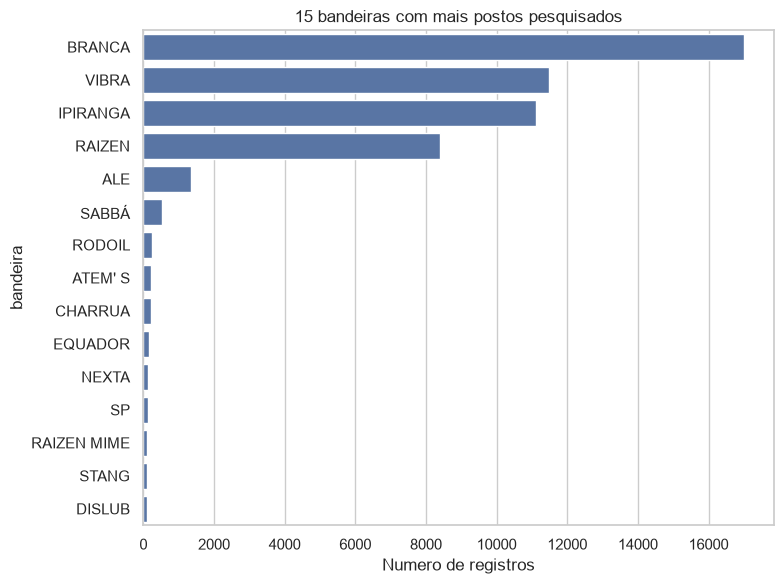

In [14]:
top_bandeiras = df['bandeira'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_bandeiras.values, y=top_bandeiras.index, ax=ax, orient='h')
ax.set_title('15 bandeiras com mais postos pesquisados')
ax.set_xlabel('Numero de registros')
plt.tight_layout()
plt.show()

**Resultado:** a distribuicao por bandeira e bem menos concentrada que por estado/produto — nenhuma bandeira domina o dataset. Por isso `bandeira` fica de fora das features numericas por enquanto (so `produto` e `regiao` entram como categoricas no preprocessador), mas continua disponivel nas tabelas de inspecao de anomalias.

## 8. Explorando possiveis anomalias (visual, sem treinar modelo)

Como referencia — e so como EDA, sem ajustar nenhum modelo de sklearn — vemos quantos registros ficam a mais de 3 desvios-padrao da media de preco do seu proprio grupo (estado + produto). Isso da uma nocao de escala: quantos casos 'obviamente estranhos' ja aparecem so com estatistica descritiva, antes de qualquer IsolationForest/LOF/OneClassSVM.

In [15]:
grupo = df.groupby(['estado', 'produto'])['valor_venda']
media_grupo = grupo.transform('mean')
desvio_grupo = grupo.transform('std')
z_score = (df['valor_venda'] - media_grupo) / desvio_grupo

candidatos_outlier = df[z_score.abs() > 3]
print('Registros com |z-score| > 3 dentro do grupo estado+produto:', len(candidatos_outlier))
print(f'Isso e {len(candidatos_outlier) / len(df):.2%} do total — poucos, como esperado.')
candidatos_outlier[['estado', 'municipio', 'revenda', 'produto', 'valor_venda', 'bandeira']].sort_values('valor_venda', ascending=False).head(10)

Registros com |z-score| > 3 dentro do grupo estado+produto: 396
Isso e 0.76% do total — poucos, como esperado.


,estado,municipio,revenda,produto,valor_venda,bandeira
46391,SP,BARUERI,AUTO POSTO DUQUE CONDE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.59,VIBRA
34972,SP,BARUERI,FGN COMERCIAL LTDA,GASOLINA ADITIVADA,9.49,VIBRA
34987,SP,BARUERI,CENTRO AUTOMOTIVO ALPHA CENTER LTDA,GASOLINA ADITIVADA,9.49,VIBRA
3761,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
24986,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
46867,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
36192,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
14238,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
13118,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.29,VIBRA
13117,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA,9.29,VIBRA


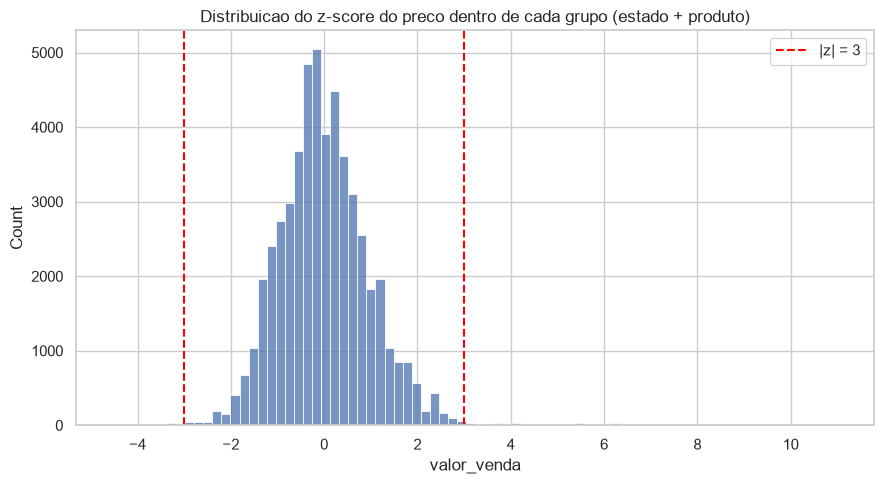

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(z_score.dropna(), bins=80, ax=ax)
ax.axvline(3, color='red', ls='--', label='|z| = 3')
ax.axvline(-3, color='red', ls='--')
ax.set_title('Distribuicao do z-score do preco dentro de cada grupo (estado + produto)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/eda_zscore_preco_grupo.png', dpi=120)
plt.show()

**Resultado:** apenas 396 registros (0,76% do total) passam de 3 desvios-padrao do seu grupo — confirma numericamente que anomalias sao raras neste dataset, na faixa de 1% ou menos, coerente com o `contamination` inicial de 2% usado como baseline no notebook 02. O histograma do z-score mostra uma distribuicao concentrada perto de zero com caudas curtas, exatamente o padrao esperado quando poucos pontos sao verdadeiramente anomalos.

## 9. Conclusoes da EDA

- O dataset tem 52.336 registros, sem nulos e sem duplicadas, com uma unica coluna numerica relevante (`valor_venda`) e fortes efeitos de grupo por `estado` e `produto`.
- Preco bruto sozinho **nao** e uma boa feature de anomalia: R$ 6,50 e comum no Acre (mediana de gasolina R$ 7,39) e seria um outlier forte no Piaui (mediana R$ 5,79). Faz mais sentido usar o desvio do preco em relacao a mediana do proprio grupo (estado + produto).
- Menos de 1% dos registros passam de 3 desvios-padrao do seu grupo (396 de 52.336) — confirma que anomalias sao raras, como esperado no problema.
- Nao ha rotulo de fraude/erro: a avaliacao de precision/recall dos modelos vai precisar de anomalias sinteticas injetadas (feito no notebook `04_avaliacao_tuning`).

**Proximo passo:** `02_preprocessing_baseline.ipynb` — split treino/teste, engenharia de features (desvio vs. mediana do grupo, ajustado somente no treino) e um modelo baseline de IsolationForest.